<a href="https://colab.research.google.com/github/Subroy1/MSAI_AllPracticeModules/blob/main/Module%2010/week10_video3_autocorrelations_filled.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# [statsmodels](https://www.statsmodels.org/stable/index.html),  [datasets](https://www.statsmodels.org/stable/datasets/index.html#datasets)

# Create a stationary time series

In [3]:
import statsmodels.tsa.arima_process as arima_process

In [4]:
process = arima_process.ArmaProcess(ar=[1,-0.8], ma=[1])


In [5]:
process

ArmaProcess([1.0, -0.8], [1.0], nobs=100) at 0x7b0af452c7a0

## Take a sample

In [6]:
z = process.generate_sample(nsample=100)
z

array([ 1.11537754,  0.64031758,  0.39600857,  2.49953004,  2.47612104,
        1.60522669, -0.35653651, -0.13492726,  1.95691311,  2.3554254 ,
        2.25272738,  1.36066374,  1.04355806,  0.74044251, -1.06366695,
       -1.1670455 , -0.49121698, -0.75870765, -1.85969069, -1.27644279,
       -0.50301983, -0.88648061, -2.16279331, -1.50975514,  0.79950734,
        0.48648625,  0.98501793, -0.05408473,  1.07033701, -1.59378302,
       -0.12524881, -0.45183282, -1.0879151 , -0.01323096, -1.52372891,
       -1.34055912,  0.78803452, -0.28354236, -0.19695688, -1.4565735 ,
       -0.24312496, -1.05401936, -1.2026662 , -1.20768036, -0.39973306,
       -1.44068776, -2.03015483,  0.44003999, -1.5284067 , -3.40785584,
       -0.67749792,  1.19168119,  1.78970997,  1.42576961,  3.06164365,
        3.71756646,  3.77730745,  2.07644621,  3.80802583,  2.40135902,
        3.08023331,  2.6546882 ,  1.87598641,  0.52296834,  0.62233215,
       -0.26842577, -0.11878341,  0.656153  ,  1.8287787 ,  0.48

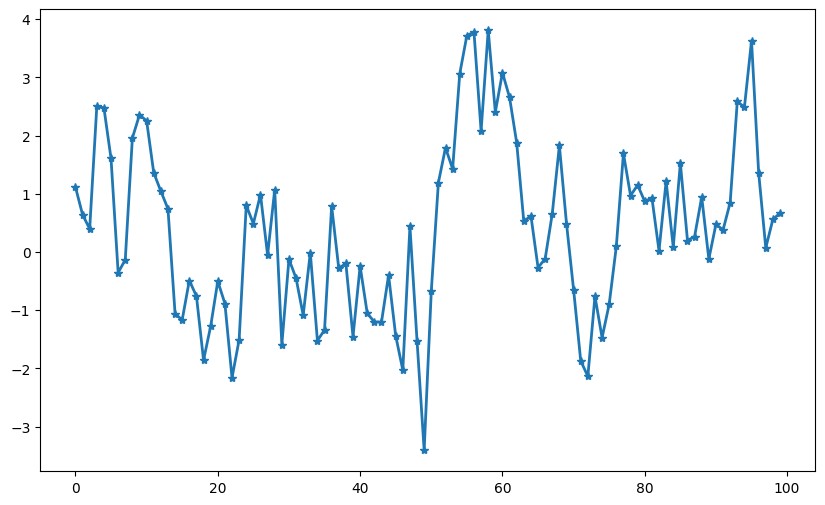

In [7]:
plt.figure(figsize=(10,6))
plt.plot(z, linewidth=2, marker='*')


# Plotting autocorrelations (These are theoretical AC on the process and pass in the number of lags)

In [8]:
acf = process.acf(lags=20)
acf

#Autocorrelation: This measures the correlation between a time series and a lagged version of itself. In simpler terms, it tells you how much an observation at time t is related to an observation at time t-k (where k is the lag).
#Lag: When you specify lags=20 (as in acf = process.acf(lags=20)), you are asking the function to calculate the autocorrelation for various time differences, specifically for k = 1, 2, 3, ..., 20.
#Lag 20: Measures the correlation between y_t and y_{t-20}.
#By plotting the ACF across different lags, you can see how the correlation decays over time, which is crucial for identifying the underlying structure of a time series model (e.g., whether it's an AR, MA, or ARIMA process).
# AC values will tend to be 0 as the lag increases because for a stationary process , the AC will decay over time .

array([1.        , 0.8       , 0.64      , 0.512     , 0.4096    ,
       0.32768   , 0.262144  , 0.2097152 , 0.16777216, 0.13421773,
       0.10737418, 0.08589935, 0.06871948, 0.05497558, 0.04398047,
       0.03518437, 0.0281475 , 0.022518  , 0.0180144 , 0.01441152])

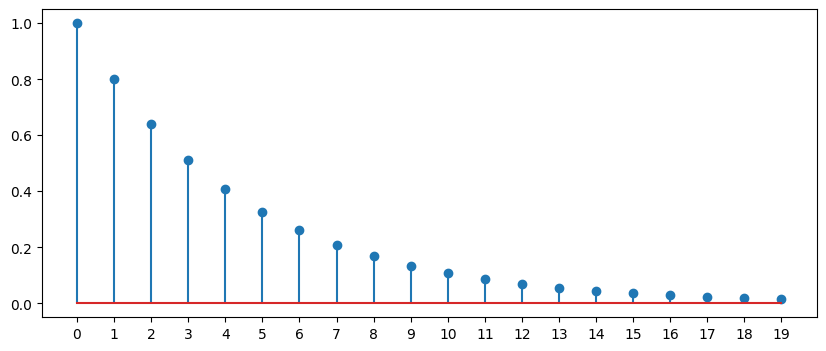

In [9]:
plt.figure(figsize=(10,4))
plt.stem(acf)#is a discrete sequence plot where values are displayed as lines (stems) extending from a baseline to the data point,
plt.xticks(ticks=range(0,20,1))
plt.show()

# Plotting sample autocorrelations

In [10]:
import statsmodels.graphics.tsaplots as tsaplots
# Theoretical vs. Empirical: The first is based on the model's definition, while the second is based on observed data.
# Sampling Variability: The theoretical ACF is fixed for a given model, while the sample ACF will vary slightly each time you generate a new sample (even from the same process).


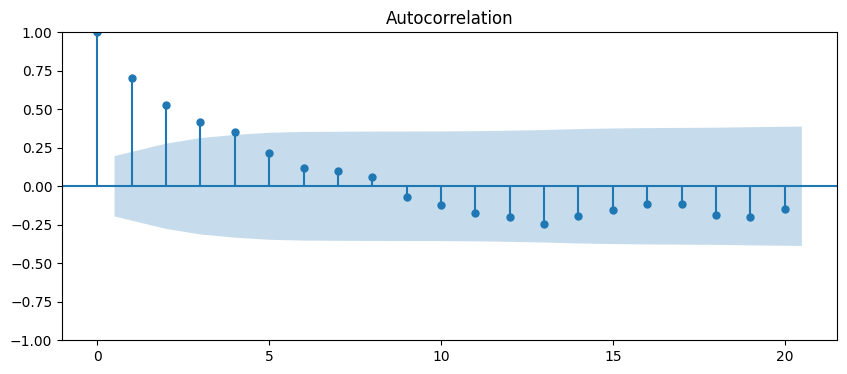

In [11]:
fig, ax = plt.subplots(figsize=(10,4))
tsaplots.plot_acf(z,lags=20, ax=ax)
plt.show()
# once the autocorelations enter blue region , we cannnot reject the hypothesis that the ACs equal to 0 within the blue region (95% confidence interval).
# the blue region is the confidence interval where ACs may not be meaningful because if they are non 0 , it could be due to chance and true AC at these lags can be 0 .

# Load sunspots data

In [13]:
sunspots = pd.read_csv('/content/sample_data/Sunspots.csv')
sunspots.head()

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
0,0,1749-01-31,96.7
1,1,1749-02-28,104.3
2,2,1749-03-31,116.7
3,3,1749-04-30,92.8
4,4,1749-05-31,141.7


In [15]:
sunspots.loc[1,"Date"]

'1749-02-28'

In [17]:
pd.to_datetime(sunspots['Date'])

,Date
0,1749-01-31
1,1749-02-28
2,1749-03-31
3,1749-04-30
4,1749-05-31
...,...
3260,2020-09-30
3261,2020-10-31
3262,2020-11-30
3263,2020-12-31


In [18]:
sunspots.set_index(pd.to_datetime(sunspots['Date']), inplace=True)
sunspots.head()

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
Date,,,
1749-01-31,0,1749-01-31,96.7
1749-02-28,1,1749-02-28,104.3
1749-03-31,2,1749-03-31,116.7
1749-04-30,3,1749-04-30,92.8
1749-05-31,4,1749-05-31,141.7


In [23]:
sunspots.drop(columns=['Unnamed: 0','Date'], inplace=True)
sunspots.head(2)


,Monthly Mean Total Sunspot Number
Date,
1749-01-31,96.7
1749-02-28,104.3


In [24]:
sunspots.dropna(axis=1)

,Monthly Mean Total Sunspot Number
Date,
1749-01-31,96.7
1749-02-28,104.3
1749-03-31,116.7
1749-04-30,92.8
1749-05-31,141.7


In [25]:
sunspots.rename(columns={"Monthly Mean Total Sunspot Number":"values"}, inplace=True)

In [26]:
sunspots.head()

,values
Date,
1749-01-31,96.7
1749-02-28,104.3
1749-03-31,116.7
1749-04-30,92.8
1749-05-31,141.7


<Axes: xlabel='Date'>

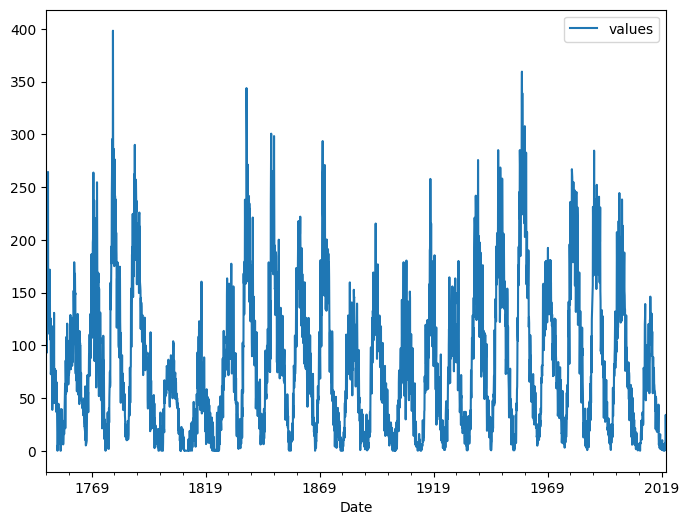

In [29]:
sunspots.plot(figsize=(8,6))
# this sunspot data is probably not stationary because stationary data does not have such oscillations .
#this data shows that number of spots decreases to 0 every decade or so ~ 11 solar years.

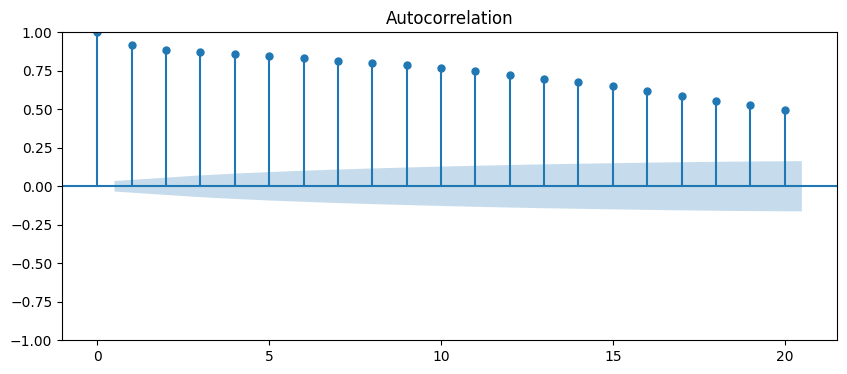

In [31]:
fig,ax = plt.subplots (figsize=(10,4))
# plot the sample autocorelation function
tsaplots.plot_acf(sunspots,lags=20, ax=ax)
plt.show()

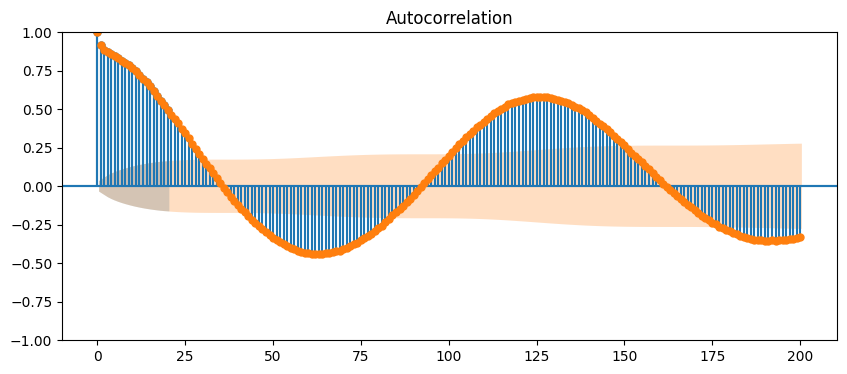

In [32]:
# above plot shows autocorelation decreasing very slowly and does not capture complete trend , hence increase the lag to 200.
tsaplots.plot_acf(sunspots,lags=200, ax=ax)
#Even after 200 lags , it does not decay , hence the sunspots data is not stationary .


# Take a difference One apporach  is to take differential of consecutive times

In [33]:
diff_sunspots = sunspots.diff().dropna()
diff_sunspots

,values
Date,
1749-02-28,7.6
1749-03-31,12.4
1749-04-30,-23.9
1749-05-31,48.9
1749-06-30,-2.5
...,...
2020-09-30,-6.9
2020-10-31,13.8
2020-11-30,19.6


<AxesSubplot:xlabel='Date'>

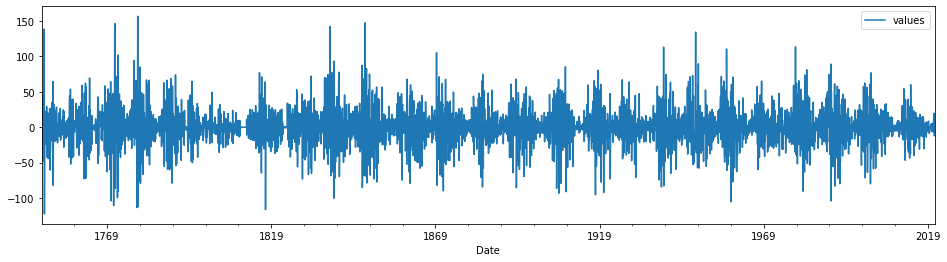

In [ ]:
diff_sunspots.plot(figsize=(16,4))

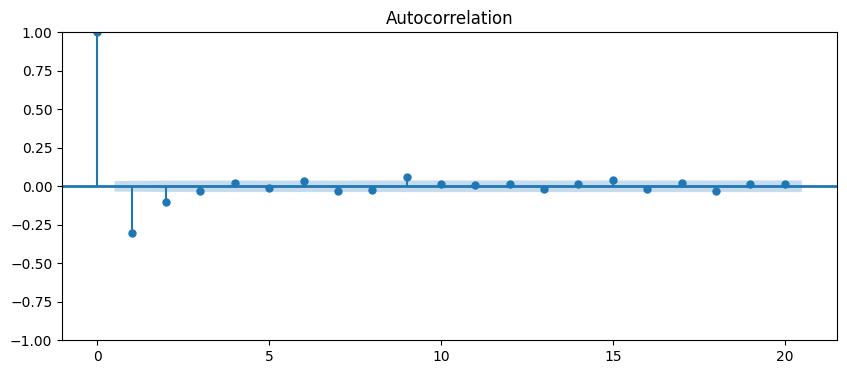

In [42]:
_, ax = plt.subplots(figsize=(10,4))
tsaplots.plot_acf(diff_sunspots, lags=20, ax=ax , linewidth=2)
plt.show()

In [ ]:
# there are 2 lags which are non zero after r=0 , and after that all the points fall under confidence interval (> 95%)
#hence the difference in sun spots in consecutive months is stationary.